In [1]:
from functools import reduce
import re
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
LOG_PATTERNS = {
    "counterexample": re.compile(r"Counter Example Mod (\d+)"),
    "now": re.compile(r"now=(\d+:\d+:\d+\.\d+)"),
    "params": re.compile(r"Parameters:\s*p\s*=\s*(\d+),\s*k\s*=\s*(\d+)"),
    "threads": re.compile(r"Spawning\s+(\d+)\s+threads"),
    "step1": re.compile(r"Step 1.*S size = (\d+)"),
    "step20": re.compile(r"\[2.0\].*S.size\(\) = (\d+)"),
    "squeeze": re.compile(r"\[2.1\]\s+squeezing\s+\(l=(\d+)\):\s+S size = (\d+)"),
    "step21_done": re.compile(r"Squeeze\s+:: Done ::\s+S.size\(\) = (\d+)"),
    "time_elapsed": re.compile(r"Time elapsed:\s*([\d.]+)\s*s"),
    "subproof_done": re.compile(r"Subproof Mod (\d+) Done"),
}

def flatten_row(d): 
    row = dict(d) 
    for l, size in d.get("squeeze_sizes", {}).items():
        row[f"squeeze_l{l}_size"] = size 
    for step, t in d.get("step_times", {}).items(): 
        row[f"time_{step}"] = t 
    row["total_time"] = sum(d.get("step_times", {}).values()) 
    row.pop("squeeze_sizes", None) 
    row.pop("step_times", None) 
    return row

def parse_log(path):
    rows = []
    current = {
        "squeeze_sizes": {},
        "step_times": {},
    }
    last_step = None

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if m := LOG_PATTERNS["params"].search(line):
                current["p"] = int(m.group(1))
                current["k"] = int(m.group(2))

            elif m := LOG_PATTERNS["threads"].search(line):
                current["threads"] = int(m.group(1))

            elif m := LOG_PATTERNS["step1"].search(line):
                current["step1_size"] = int(m.group(1))
                last_step = "step1"

            elif m := LOG_PATTERNS["step20"].search(line):
                current["step20_size"] = int(m.group(1))
                last_step = "step20"

            elif m := LOG_PATTERNS["squeeze"].search(line):
                l = int(m.group(1))
                size = int(m.group(2))
                current["squeeze_sizes"][l] = size
                last_step = f"squeeze_l{l}"

            elif m := LOG_PATTERNS["step21_done"].search(line):
                current["step21_final_size"] = int(m.group(1))
                last_step = "step21"

            elif m := LOG_PATTERNS["time_elapsed"].search(line):
                if last_step is not None:
                    current["step_times"][last_step] = float(m.group(1))
                    last_step = None

            elif m := LOG_PATTERNS["subproof_done"].search(line):
                current.setdefault("has_counterexample", False)
                rows.append(flatten_row(current))
                current = {"squeeze_sizes": {}, "step_times": {}}
                last_step = None

            elif m := LOG_PATTERNS["counterexample"].search(line):
                current["has_counterexample"] = True
                rows.append(flatten_row(current))
                current = {"squeeze_sizes": {}, "step_times": {}}
                last_step = None

    df = pd.DataFrame(rows)
    df = df.eval("thread_second_step1 = threads * time_step1")
    return df

In [3]:
def regression(df, feature, target, fit_intercept=False):
    rdf = pd.DataFrame()
    rdf["regression_x"] = df.eval(feature)
    rdf["regression_y"] = df.eval(target)
    rdf = rdf.dropna()

    X = rdf[["regression_x"]]
    y = rdf["regression_y"]

    model = LinearRegression(fit_intercept=fit_intercept)
    model.fit(X, y)

    coef = model.coef_[0]
    intercept_val = model.intercept_ if fit_intercept else 0.0

    print("Intercept:", intercept_val)
    print("Coefficient:", coef)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    print("R2:", r2)

    rdf.plot.scatter("regression_x", "regression_y")

<Axes: xlabel='p', ylabel='step1_size'>

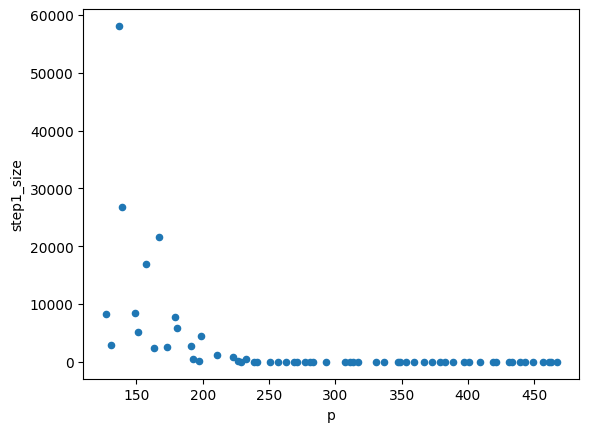

In [4]:
parse_log("./run_10").plot.scatter("p", "step1_size")

In [5]:
df = parse_log("./run_10")
df.iloc[df["step1_size"].argmax()]

p                        137
k                         10
threads                   12
step1_size             58087
step20_size            58086
step21_final_size        0.0
has_counterexample     False
squeeze_l2_size        529.0
squeeze_l4_size          2.0
time_step1             0.439
time_step20              0.1
time_step21             0.77
total_time             1.309
squeeze_l8_size          0.0
thread_second_step1    5.268
Name: 2, dtype: object

Intercept: 0.0
Coefficient: 8.304506144868453e-12
R2: 0.9517009394104272


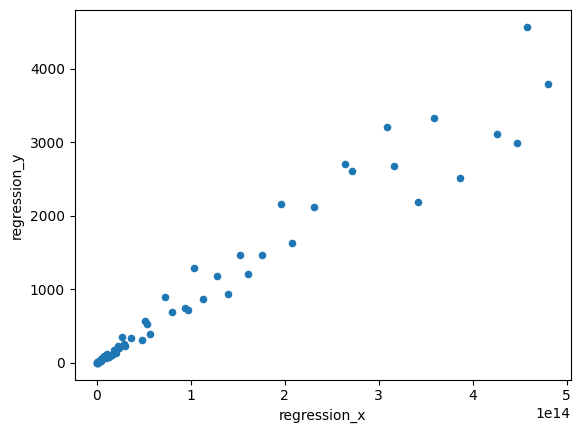

In [6]:
regression(parse_log("./run_10"), "p**5.5", "thread_second_step1")

In [7]:
parse_log("./run_9")

,p,k,threads,step1_size,has_counterexample,time_step1,total_time,thread_second_step1
0,19,9,1,1,True,0.000142,0.000142,0.000142
1,53,9,5,4651,True,0.013895,0.013895,0.069475
2,59,9,5,831,True,0.003906,0.003906,0.019530
3,67,9,6,6422,True,0.015554,0.015554,0.093324
4,71,9,7,16776,True,0.028167,0.028167,0.197169
5,73,9,7,9803,True,0.016234,0.016234,0.113638
6,79,9,7,1298,True,0.003452,0.003452,0.024164
7,83,9,8,14422,True,0.021270,0.021270,0.170160
8,89,9,8,1382,True,0.005411,0.005411,0.043288
9,97,9,9,1910,True,0.009620,0.009620,0.086580


Intercept: 0.0
Coefficient: 2.4998588765617098e-11
R2: 0.9593375683514211


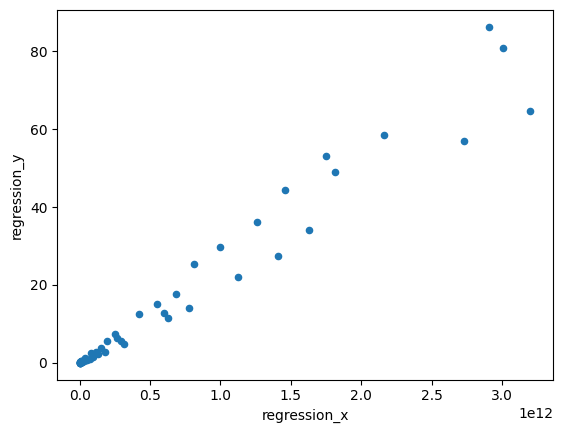

In [8]:
regression(parse_log("./run_9"), "p**5", "thread_second_step1")

Intercept: 0.0
Coefficient: 5.83419392662021e-11
R2: 0.9570590122380336


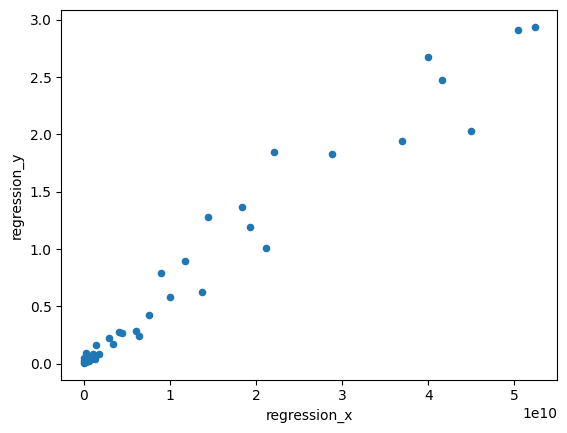

In [9]:
regression(parse_log("./run_8"), "p**4.5", "thread_second_step1")

Intercept: 0.0
Coefficient: 1.3794375523319612e-10
R2: 0.9521251662901916


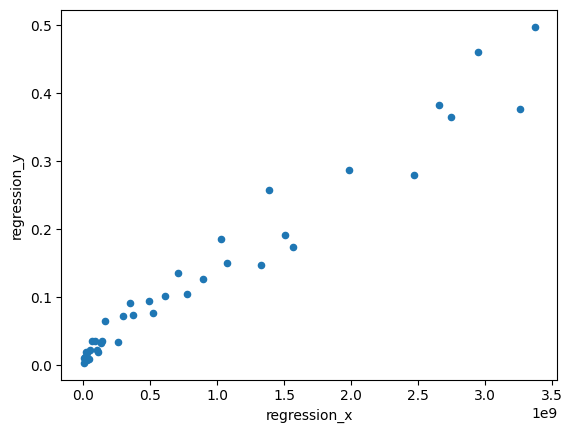

In [10]:
regression(parse_log("./run_7"), "p**4", "thread_second_step1")

Intercept: 0.0
Coefficient: 3.800442777543722e-10
R2: 0.952037880247609


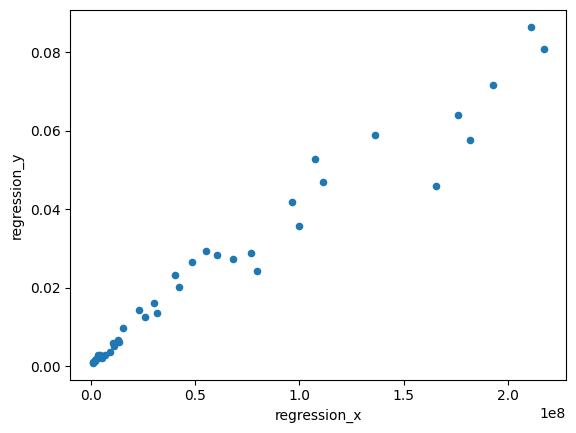

In [11]:
regression(parse_log("./run_6.l2"), "p**3.5", "thread_second_step1")

In [12]:
betas = [(10, 8.304506144868453e-12), (9, 2.4998588765617098e-11), (8, 5.83419392662021e-11), (7, 1.3794375523319612e-10), (6, 3.800442777543722e-10)]

Intercept: 0.0
Coefficient: 1.4159186450218646e-07
R2: 0.9923714070922628


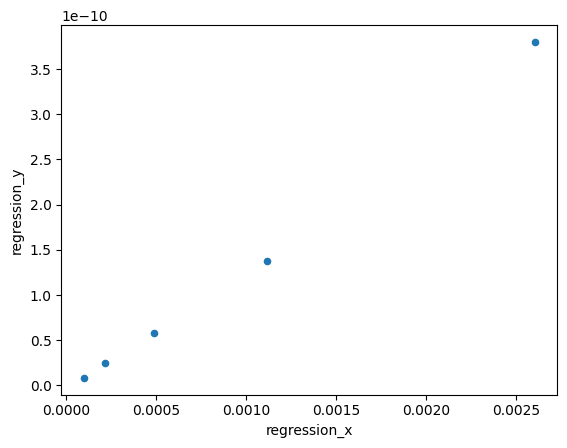

In [13]:
B = pd.DataFrame(betas)
B.columns = ["k", "beta"]
regression(B, "1 / (k * 2**k)", "beta")

In [14]:
estimate_kbeta = lambda k : 1.4159186450218646e-07 / (k * 2**k)
estimate_thread_second = lambda k, p : estimate_kbeta(k) * p**((k+1)/2)

In [15]:
p10 = [127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191,
       193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263,
       269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347,
       349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421,
       431, 433, 439, 443, 449, 457, 461, 463, 467]
seconds = sum(estimate_thread_second(10, p) for p in p10) / 20
seconds / 3600

1.2566799464827343

In [16]:
p11 = [ 23,  131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227,
        229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337,
        347, 349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431, 433, 439, 443, 449,
        457, 461, 463, 467, 479, 487, 491, 499, 503, 509, 521, 523, 541, 547, 557, 563, 569, 571, 577]
seconds = sum(estimate_thread_second(11, p) for p in p11) / 20
seconds / 3600

41.95078702894491

In [17]:
p12 = [139, 149, 151, 167, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229, 233,
       239, 251, 257, 263, 269, 271, 277, 281, 283, 307, 311, 313, 347, 379, 433,
       241, 293, 317, 331, 337, 349, 353, 359, 367, 373, 383, 389, 397, 401, 409,
       419, 421, 431, 433, 439, 443, 503, 509, 521, 523, 571, 577, 613, 617, 619,
       541, 547, 557, 599, 601, 607, 631, 641, 659, 661, 677, 683]

seconds = sum(estimate_thread_second(12, p) for p in p12) / 20
seconds / 3600

1099.6034750530791

# min l

In [43]:
def extract_min_l(df):
    l_cols = [
        c for c in df.columns
        if re.match(r"squeeze_l\d+_size", c)
    ]

    records = []
    for _, row in df.iterrows():
        if row.get("step20_size", None) == 0:
            min_l = 1
        else:
            min_l = None
            for c in sorted(l_cols, key=lambda x: int(re.search(r"\d+", x).group())):
                if row[c] == 0:
                    min_l = int(re.search(r"\d+", c).group())
                    break

        records.append({"p": row["p"], "min_l": min_l})

    return pd.DataFrame(records)

In [60]:
def extract_min_l_from(filenames):
    if len(filenames) == 1:
        df = extract_min_l(parse_log(filenames[0]))
        return df

    dfs = [extract_min_l(parse_log(fn)) for fn in filenames]

    merged = reduce(
        lambda left, right: pd.merge(left, right, on="p", how="outer"),
        dfs,
    )

    min_l_cols = merged.filter(regex=r"^min_l").columns
    merged["mn"] = merged[min_l_cols].min(axis=1)

    return merged[["p", "mn"]].rename(columns={"mn": "min_l"})

<Axes: xlabel='p', ylabel='min_l'>

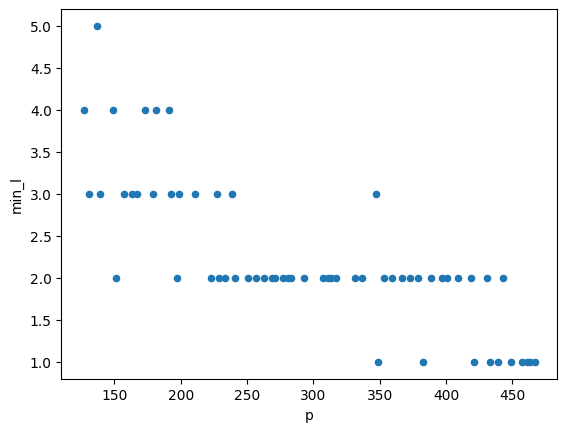

In [73]:
merged = extract_min_l_from(["./run_10", "./run_10.l3", "./run_10.l5"])

merged.plot.scatter("p", "min_l")

<Axes: xlabel='p', ylabel='min_l'>

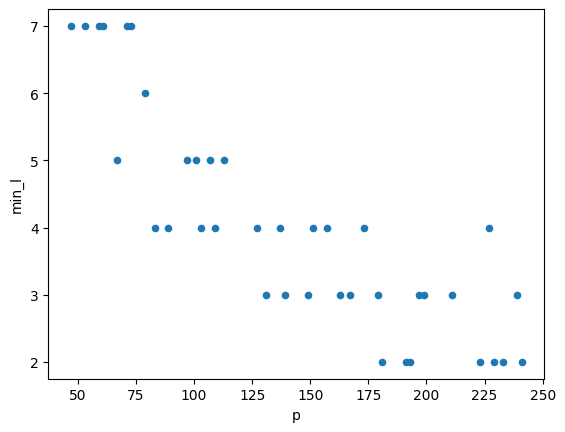

In [74]:
merged = extract_min_l_from(["./run_6.l2", "./run_6.l3", "./run_6.l5"])

# Manual
for p in [67, 79, 83, 89, 97] :
    mask = merged["p"] == p
    merged.loc[mask, "min_l"] = merged.loc[mask, "min_l"].clip(upper=6)
merged.loc[merged["min_l"].notna(), "min_l"] = merged.loc[merged["min_l"].notna(), "min_l"].clip(upper=7)

merged.plot.scatter("p", "min_l")